In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
# Load dataset
df = pd.read_csv(
    "../data/spam_data.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Clean dataset
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Convert labels
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

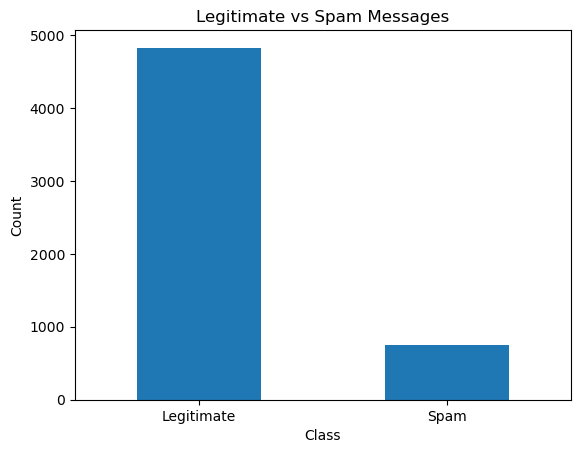

In [9]:
# Check class distribution
df["label"].value_counts()

df["label"].value_counts().plot(kind="bar")
plt.title("Legitimate vs Spam Messages")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Legitimate", "Spam"], rotation=0)
plt.show()

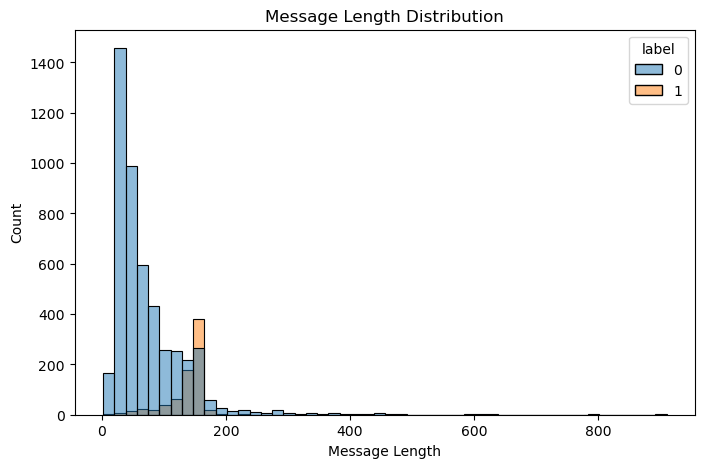

In [11]:
# Text length analysis 
df["message_length"] = df["message"].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="message_length", hue="label", bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.show()

In [13]:
# Prepare features and target
X = df["message"]
y = df["label"]

In [15]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# Train models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Naive Bayes": MultinomialNB()
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=5000
        )),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Naive Bayes
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982063,0.944828,0.919463,0.931973
1,Naive Bayes,0.972197,0.991667,0.798658,0.884758


In [19]:
# CHoose best models
best_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

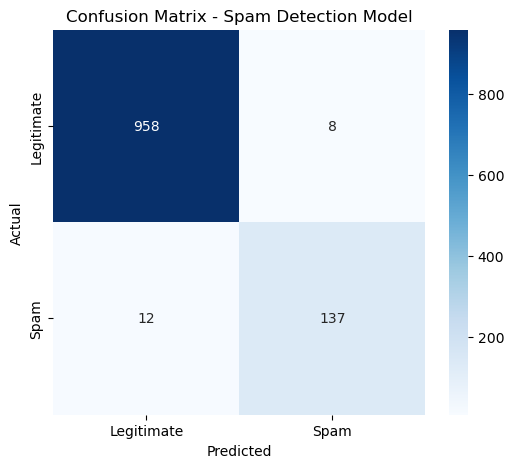

In [21]:
# COnfusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Spam"],
    yticklabels=["Legitimate", "Spam"]
)

plt.title("Confusion Matrix - Spam Detection Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Sample prediction
sample_messages = [
    "Congratulations! You have won a free prize. Claim now.",
    "Hi, are we still meeting at 6pm today?",
    "URGENT! Your account has been selected for a cash reward.",
    "Can you send me the report when you get a chance?"
]

for msg in sample_messages:
    prediction = best_model.predict([msg])[0]
    probability = best_model.predict_proba([msg])[0][1] * 100

    print("Message:", msg)
    print("Prediction:", "Spam" if prediction == 1 else "Legitimate")
    print(f"Spam Probability: {probability:.2f}%")
    print("-" * 80)

Message: Congratulations! You have won a free prize. Claim now.
Prediction: Spam
Spam Probability: 98.44%
--------------------------------------------------------------------------------
Message: Hi, are we still meeting at 6pm today?
Prediction: Legitimate
Spam Probability: 10.12%
--------------------------------------------------------------------------------
Message: URGENT! Your account has been selected for a cash reward.
Prediction: Spam
Spam Probability: 89.92%
--------------------------------------------------------------------------------
Message: Can you send me the report when you get a chance?
Prediction: Legitimate
Spam Probability: 35.61%
--------------------------------------------------------------------------------


In [25]:
# Extract top spam keywords
vectorizer = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]

keyword_df = pd.DataFrame({
    "Keyword": feature_names,
    "Spam_Weight": coefficients
}).sort_values(by="Spam_Weight", ascending=False)

keyword_df.head(20)

,Keyword,Spam_Weight
4679,txt,5.354678
4695,uk,4.277237
3211,mobile,3.851621
810,claim,3.809470
4938,www,3.744005
4210,service,3.542785
4061,reply,3.503205
4412,stop,3.496652
1710,free,3.489476
119,150p,3.455647


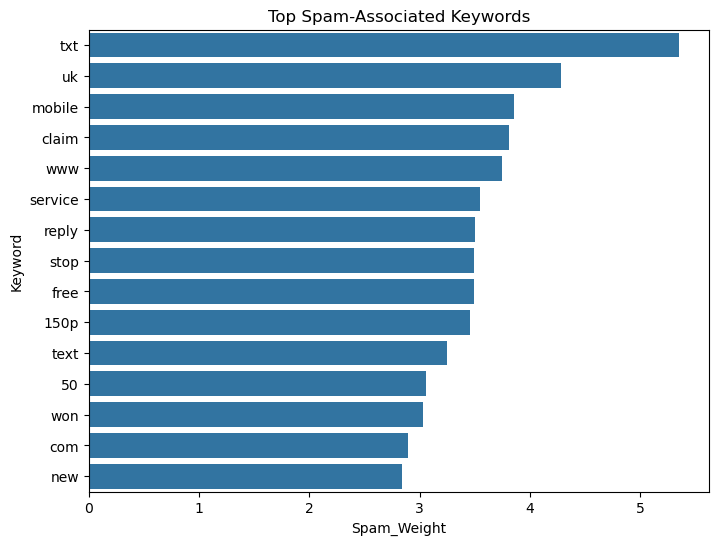

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=keyword_df.head(15),
    x="Spam_Weight",
    y="Keyword"
)

plt.title("Top Spam-Associated Keywords")
plt.show()

In [29]:
# Save files
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

joblib.dump(best_model, "../models/spam_model.pkl")
joblib.dump(X_test, "../models/sample_messages.pkl")
joblib.dump(keyword_df, "../models/spam_keywords.pkl")

results_df.to_csv("../reports/spam_model_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [31]:
# test saved model
loaded_model = joblib.load("../models/spam_model.pkl")

test_message = "You have won free cash. Click now to claim your prize."

prediction = loaded_model.predict([test_message])[0]
probability = loaded_model.predict_proba([test_message])[0][1] * 100

print("Prediction:", "Spam" if prediction == 1 else "Legitimate")
print(f"Spam Probability: {probability:.2f}%")

Prediction: Spam
Spam Probability: 98.83%


In [33]:
# False positive / false negative analysis
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 958
False Positives: 8
False Negatives: 12
True Positives: 137


In [35]:
# Confidence score dataframe
spam_probabilities = best_model.predict_proba(X_test)[:, 1]

confidence_df = pd.DataFrame({
    "Message": X_test,
    "Actual": y_test,
    "Predicted": y_pred_best,
    "SpamProbability": spam_probabilities
})

confidence_df.head()

,Message,Actual,Predicted,SpamProbability
2826,"Oh right, ok. I'll make sure that i do loads o...",0,0,0.037990
3695,I am in tirupur. call you da.,0,0,0.089540
3906,No that just means you have a fat head,0,0,0.104341
575,"You have won ?1,000 cash or a ?2,000 prize! To...",1,1,0.959459
2899,Come aftr &lt;DECIMAL&gt; ..now i m cleaning ...,0,0,0.037492


In [37]:
# Highest risk messages
confidence_df.sort_values(
    "SpamProbability",
    ascending=False
).head(10)

,Message,Actual,Predicted,SpamProbability
672,Get ur 1st RINGTONE FREE NOW! Reply to this ms...,1,1,0.994124
12,URGENT! You have won a 1 week FREE membership ...,1,1,0.993729
2219,You have WON a guaranteed å£1000 cash or a å£2...,1,1,0.993693
504,+123 Congratulations - in this week's competit...,1,1,0.986202
3761,FREE for 1st week! No1 Nokia tone 4 ur mob eve...,1,1,0.985459
1672,URGENT! We are trying to contact U. Todays dra...,1,1,0.984557
2685,URGENT! We are trying to contact U. Todays dra...,1,1,0.984557
1520,"URGENT! Your Mobile No was awarded a å£2,000 B...",1,1,0.982074
5278,URGENT! Your Mobile number has been awarded wi...,1,1,0.980846
803,You have won a guaranteed å£200 award or even ...,1,1,0.980549


In [39]:
# Misclassified messages
wrong_predictions = confidence_df[
    confidence_df["Actual"] != confidence_df["Predicted"]
]

wrong_predictions.head(10)

,Message,Actual,Predicted,SpamProbability
3748,Dear Voucher Holder 2 claim your 1st class air...,1,0,0.434155
573,Waiting for your call.,0,1,0.506253
3979,ringtoneking 84484,1,0,0.206400
3358,Sorry I missed your call let's talk when you h...,1,0,0.058587
5449,"Latest News! Police station toilet stolen, cop...",1,0,0.338811
152,Ok... Ur typical reply...,0,1,0.588533
760,"Romantic Paris. 2 nights, 2 flights from å£79 ...",1,0,0.418992
1939,More people are dogging in your area now. Call...,1,0,0.359713
1429,For sale - arsenal dartboard. Good condition b...,1,0,0.238833
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,1,0,0.212410


In [ ]:
# Suspicious keyword matching
suspicious_words = [
    "free", "win", "winner", "cash", "prize",
    "urgent", "claim", "click", "call", "now",
    "reward", "selected", "account", "verify"
]

def find_suspicious_words(message):
    found = []
    message_lower = message.lower()

    for word in suspicious_words:
        if word in message_lower:
            found.append(word)

    return found

confidence_df["SuspiciousWords"] = confidence_df["Message"].apply(find_suspicious_words)

confidence_df.head()

In [41]:
# Save confidence data for UI
joblib.dump(confidence_df, "../models/spam_confidence_data.pkl")

['../models/spam_confidence_data.pkl']

## Research Question

Can machine learning accurately classify messages as spam or legitimate, and can interpretable NLP techniques explain why certain messages are flagged as suspicious?

## NLP Preprocessing

The text data was transformed using TF-IDF vectorisation. TF-IDF gives higher importance to words that are frequent in a message but less common across the full dataset. This allows the model to identify words that are more strongly associated with spam messages.

In [50]:
# Class imbalance
class_distribution = df["label"].value_counts(normalize=True) * 100
class_distribution

label
0    86.593683
1    13.406317
Name: proportion, dtype: float64

## Class Imbalance

The dataset contains more legitimate messages than spam messages. This means accuracy alone may not be sufficient, because a model could appear accurate while still missing spam messages. Therefore, precision, recall and F1-score were also used.

ROC-AUC: 0.9870635152222547


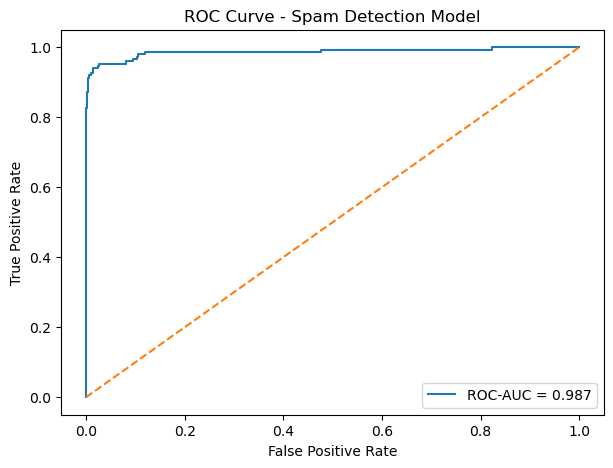

In [55]:
# ROC-AUC score
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_best = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_best)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spam Detection Model")
plt.legend()
plt.show()

In [57]:
# Error analysis section
wrong_predictions.head(10)

,Message,Actual,Predicted,SpamProbability
3748,Dear Voucher Holder 2 claim your 1st class air...,1,0,0.434155
573,Waiting for your call.,0,1,0.506253
3979,ringtoneking 84484,1,0,0.206400
3358,Sorry I missed your call let's talk when you h...,1,0,0.058587
5449,"Latest News! Police station toilet stolen, cop...",1,0,0.338811
152,Ok... Ur typical reply...,0,1,0.588533
760,"Romantic Paris. 2 nights, 2 flights from å£79 ...",1,0,0.418992
1939,More people are dogging in your area now. Call...,1,0,0.359713
1429,For sale - arsenal dartboard. Good condition b...,1,0,0.238833
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,1,0,0.212410


## Error Analysis

Misclassified messages were reviewed to understand model limitations. False positives may cause legitimate messages to be incorrectly flagged, while false negatives may allow spam messages to pass through undetected.

In [60]:
# Explainability 
keyword_df.head(20)

,Keyword,Spam_Weight
4679,txt,5.354678
4695,uk,4.277237
3211,mobile,3.851621
810,claim,3.809470
4938,www,3.744005
4210,service,3.542785
4061,reply,3.503205
4412,stop,3.496652
1710,free,3.489476
119,150p,3.455647


## Explainability

The Logistic Regression model allows inspection of feature coefficients. Words with stronger positive weights are more associated with spam predictions. This provides a simple explanation of why the model flags certain messages.

## Ethical and Security Considerations

This project is defensive and educational. It does not send emails, scan inboxes, collect personal messages or perform live monitoring.

A real spam detection system must consider privacy, false positives, user consent and transparency. Incorrectly blocking legitimate messages could cause users to miss important information, while missing spam could expose users to scams or phishing attempts.

## Limitations

The dataset is relatively small and based on SMS-style messages, so the model may not generalise well to modern email phishing attempts. The model also relies on text patterns and does not inspect attachments, URLs, sender reputation or email headers.

## Future Work

Future improvements could include:
- larger email datasets such as Enron
- phishing-specific labels
- URL and sender analysis
- transformer-based models
- SHAP explanations
- deployment as a Streamlit dashboard

## Conclusion

This notebook developed a proof-of-concept spam detection system using Natural Language Processing.

TF-IDF vectorisation was used to convert message text into numerical features, and Logistic Regression and Naive Bayes models were compared using accuracy, precision, recall and F1-score.

The final model can classify messages as legitimate or spam and provide interpretable spam-associated keywords.

This project demonstrates how NLP can support defensive cybersecurity tasks such as spam and suspicious message filtering.